# Notebook 01 — Lesion segmentation (scratch U-Net)

This notebook trains the **from-scratch U-Net** lesion segmenter described in
the *Approach* section of the report (the scratch-segmentation baseline) and
evaluates it with the Dice score on ISIC-2018-Task-1-style data.

All real logic lives in [`src/segmentation_unet.py`](../src/segmentation_unet.py);
this notebook only glues, narrates, and plots.

**Order matters:** run this notebook *before*
[`02_lesion_focused.ipynb`](02_lesion_focused.ipynb) — it writes the checkpoint
that notebook 02 consumes.

## Setup

The opening cell records what the notebook consumes and produces, fixes seeds,
and exposes a single `SAMPLE` switch:

* `SAMPLE = True` (default) uses the tiny **synthetic** dataset from
  `python -m data_setup.make_sample_data` — runs in ~1 min on CPU with no
  credentials. This is what Binder and the website use.
* `SAMPLE = False` points at the real ISIC-2018 Task 1 data on a machine that
  has it (edit `ISIC_IMAGE_DIR` / `ISIC_MASK_DIR`).

In [1]:
# Notebook 01 — Lesion segmentation (scratch U-Net)
# Inputs:  ../data/sample/isic/{images,masks}        (SAMPLE=True)
#          ../data/isic2018/{images,masks}           (SAMPLE=False, edit below)
# Outputs: ../models/segmentation_unet_v2.pth        (checkpoint for notebook 02)
#          ../figures/seg_training_curves.png, ../figures/seg_qualitative.png
# Runtime: ~1 min on CPU in SAMPLE mode
import sys, os; sys.path.insert(0, "../src")
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, random_split

from segmentation_unet import (
    SimpleUNet, ISICSegmentationDataset,
    dice_loss_from_logits, dice_score_from_logits,
    dice_score_binary_numpy, clean_binary_mask,
)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
plt.rcParams.update({"font.size": 10, "figure.dpi": 100})

SAMPLE = True                 # <-- flip to False for the real ISIC-2018 data
RETRAIN = True                # if False, reuse an existing checkpoint
IMAGE_SIZE = 128 if SAMPLE else 256
NUM_EPOCHS = 15 if SAMPLE else 10
BATCH_SIZE = 8 if SAMPLE else 16

if SAMPLE:
    ISIC_IMAGE_DIR = "../data/sample/isic/images"
    ISIC_MASK_DIR  = "../data/sample/isic/masks"
else:
    ISIC_IMAGE_DIR = "../data/isic2018/images"   # edit to your real paths
    ISIC_MASK_DIR  = "../data/isic2018/masks"

CKPT_PATH = "../models/segmentation_unet_v2.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"SAMPLE={SAMPLE}  device={device}  epochs={NUM_EPOCHS}  image_size={IMAGE_SIZE}")
if not Path(ISIC_IMAGE_DIR).exists():
    raise FileNotFoundError(
        f"{ISIC_IMAGE_DIR} missing. In SAMPLE mode run:  "
        f"PYTHONPATH=src python -m data_setup.make_sample_data")

SAMPLE=True  device=cpu  epochs=15  image_size=128


## Data

`ISICSegmentationDataset` pairs each `<name>.jpg` with its
`<name>_segmentation.png` mask, resizes both to a square, and binarizes the
mask. We use an 80/20 train/validation split with a fixed generator seed.

In [2]:
dataset = ISICSegmentationDataset(ISIC_IMAGE_DIR, ISIC_MASK_DIR, image_size=IMAGE_SIZE)
n_total = len(dataset)
n_train = int(0.8 * n_total)
train_ds, val_ds = random_split(
    dataset, [n_train, n_total - n_train],
    generator=torch.Generator().manual_seed(SEED),
)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
print(f"{n_total} images  ->  {len(train_ds)} train / {len(val_ds)} val")

24 images  ->  19 train / 5 val


A quick look at one image/mask pair to confirm the data loads as expected:

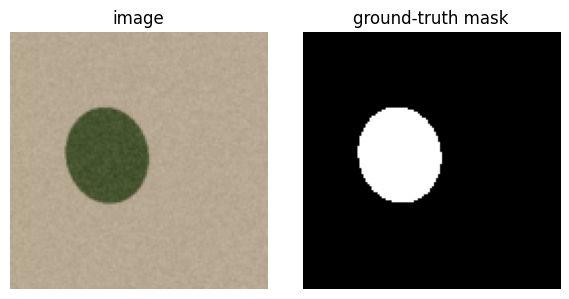

In [3]:
img0, mask0 = dataset[0]
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].imshow(img0.permute(1, 2, 0)); ax[0].set_title("image"); ax[0].axis("off")
ax[1].imshow(mask0[0], cmap="gray");  ax[1].set_title("ground-truth mask"); ax[1].axis("off")
plt.tight_layout(); plt.show()

## Model

`SimpleUNet` is a compact 3-level U-Net (channel widths 32/64/128, 256-channel
bottleneck) producing a single-channel logit map — see
[`src/segmentation_unet.py`](../src/segmentation_unet.py). We optimize a
**BCE + Dice** objective with Adam.

In [4]:
model = SimpleUNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
bce = torch.nn.BCEWithLogitsLoss()
n_params = sum(p.numel() for p in model.parameters())
print(f"SimpleUNet: {n_params/1e6:.2f}M parameters")

SimpleUNet: 1.93M parameters


## Training

Training is the only expensive step, so we follow the conditional-reload
pattern: if a checkpoint already exists and `RETRAIN` is `False`, we load it
instead of retraining. Otherwise we train for `NUM_EPOCHS` and record the loss
and validation Dice each epoch.

In [5]:
train_losses, val_losses, val_dices = [], [], []

if Path(CKPT_PATH).exists() and not RETRAIN:
    model.load_state_dict(torch.load(CKPT_PATH, map_location=device))
    print(f"Loaded existing checkpoint from {CKPT_PATH} (set RETRAIN=True to retrain)")
else:
    for epoch in range(1, NUM_EPOCHS + 1):
        model.train(); running = 0.0
        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)
            optimizer.zero_grad()
            logits = model(images)
            loss = bce(logits, masks) + dice_loss_from_logits(logits, masks)
            loss.backward(); optimizer.step()
            running += loss.item() * images.size(0)
        train_loss = running / len(train_loader.dataset)

        model.eval(); vloss = vdice = 0.0
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)
                logits = model(images)
                vloss += (bce(logits, masks) + dice_loss_from_logits(logits, masks)).item() * images.size(0)
                vdice += dice_score_from_logits(logits, masks).item() * images.size(0)
        vloss /= len(val_loader.dataset); vdice /= len(val_loader.dataset)

        train_losses.append(train_loss); val_losses.append(vloss); val_dices.append(vdice)
        print(f"epoch {epoch:2d}/{NUM_EPOCHS} | train {train_loss:.4f} | val {vloss:.4f} | val Dice {vdice:.4f}")

epoch  1/15 | train 1.2514 | val 1.4360 | val Dice 0.0000


epoch  2/15 | train 0.9636 | val 1.4219 | val Dice 0.0000


epoch  3/15 | train 0.9112 | val 1.4097 | val Dice 0.0000


epoch  4/15 | train 0.8746 | val 1.3920 | val Dice 0.0000


epoch  5/15 | train 0.8573 | val 1.3477 | val Dice 0.0000


...

epoch 11/15 | train 0.7199 | val 0.7881 | val Dice 0.9893


epoch 12/15 | train 0.7131 | val 0.7193 | val Dice 0.9911


epoch 13/15 | train 0.6880 | val 0.6919 | val Dice 0.9927


epoch 14/15 | train 0.6730 | val 0.6592 | val Dice 0.9878


epoch 15/15 | train 0.6537 | val 0.6279 | val Dice 0.9871


Training curves (skipped automatically if we reloaded a checkpoint):

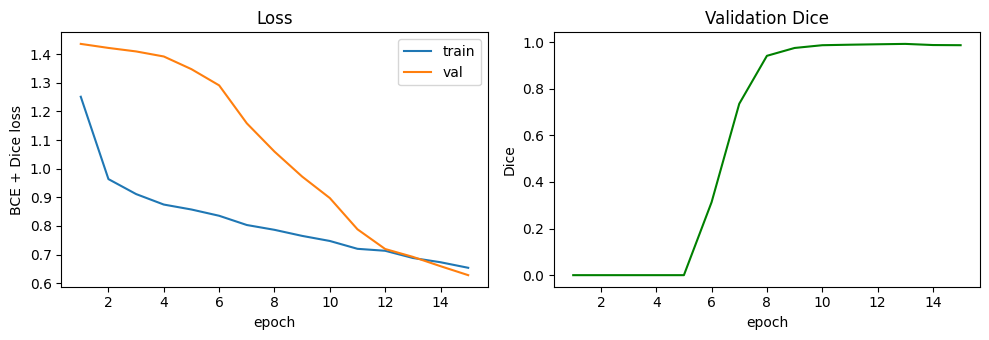

In [6]:
if train_losses:
    Path("../figures").mkdir(exist_ok=True)
    epochs = range(1, len(train_losses) + 1)
    fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
    ax[0].plot(epochs, train_losses, label="train")
    ax[0].plot(epochs, val_losses, label="val")
    ax[0].set_xlabel("epoch"); ax[0].set_ylabel("BCE + Dice loss"); ax[0].legend(); ax[0].set_title("Loss")
    ax[1].plot(epochs, val_dices, color="green")
    ax[1].set_xlabel("epoch"); ax[1].set_ylabel("Dice"); ax[1].set_title("Validation Dice")
    plt.tight_layout()
    plt.savefig("../figures/seg_training_curves.png", bbox_inches="tight")
    plt.show()
else:
    print("Reused checkpoint; no training curves to plot.")

## Threshold selection

The raw probability map is thresholded and post-processed
(`clean_binary_mask`: keep the largest connected component, fill holes). We
sweep thresholds on the validation set and keep the one with the best
post-processed Dice.

In [7]:
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
results = []
model.eval()
for thr in thresholds:
    dices = []
    with torch.no_grad():
        for images, masks in val_loader:
            probs = torch.sigmoid(model(images.to(device)))
            preds = (probs > thr).float().cpu().numpy()
            masks_np = masks.numpy()
            for i in range(preds.shape[0]):
                cleaned = clean_binary_mask(preds[i, 0])
                dices.append(dice_score_binary_numpy(cleaned, masks_np[i, 0]))
    mean_dice = float(np.mean(dices))
    results.append((thr, mean_dice))
    print(f"threshold {thr:.1f} | post-processed val Dice {mean_dice:.4f}")

best_threshold, best_dice = max(results, key=lambda x: x[1])
print(f"\nbest threshold = {best_threshold}  (val Dice {best_dice:.4f})")

threshold 0.2 | post-processed val Dice 0.7542


threshold 0.3 | post-processed val Dice 0.9612


threshold 0.4 | post-processed val Dice 0.9792


threshold 0.5 | post-processed val Dice 0.9871


threshold 0.6 | post-processed val Dice 0.9933


threshold 0.7 | post-processed val Dice 0.9924

best threshold = 0.6  (val Dice 0.9933)


## Qualitative results

Image / ground-truth / raw prediction / post-processed prediction for a few
validation examples.

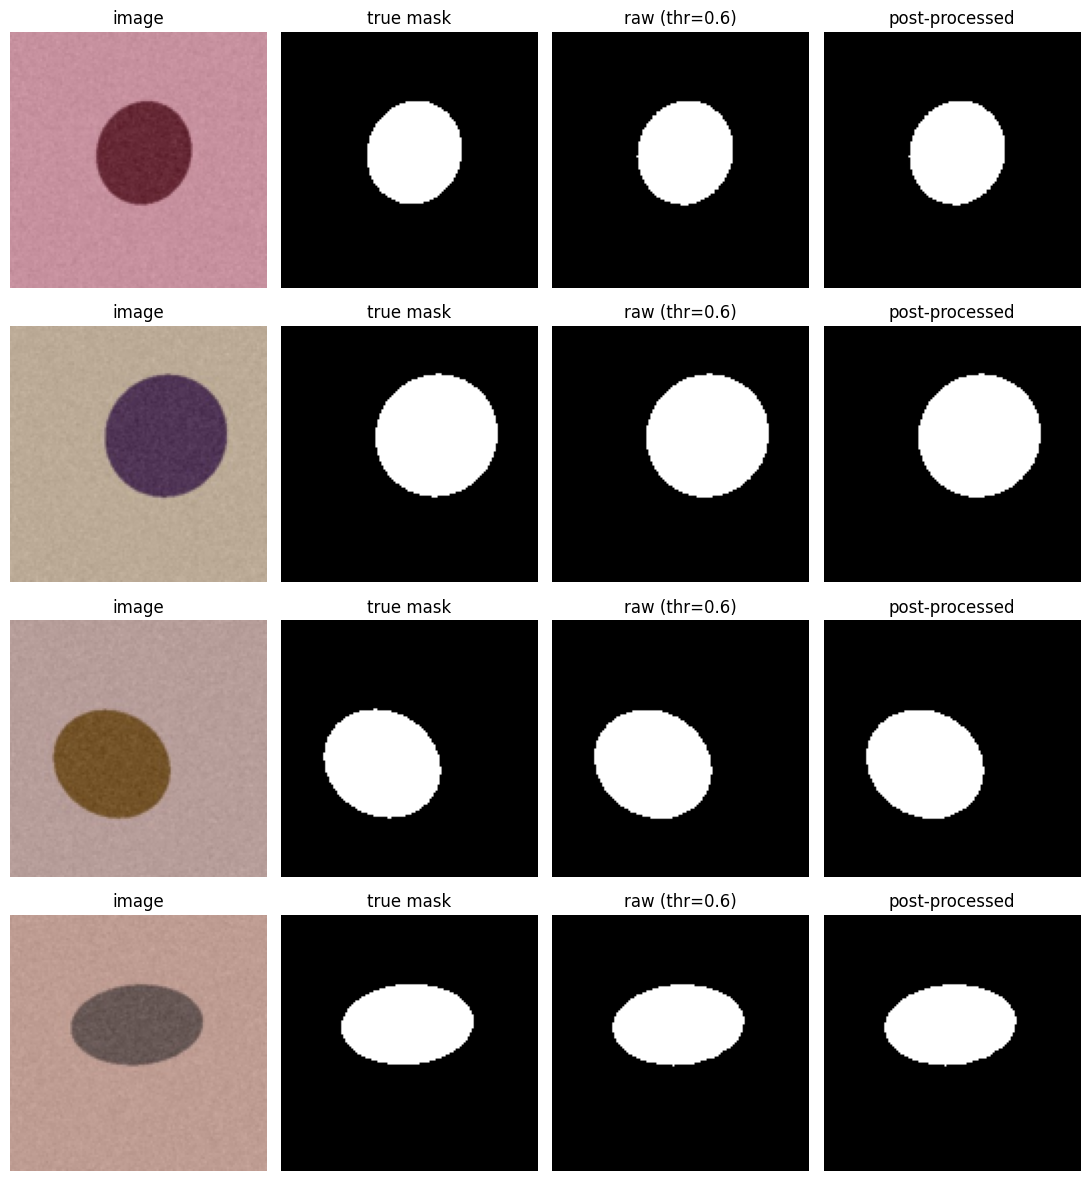

In [8]:
images, masks = next(iter(val_loader))
with torch.no_grad():
    probs = torch.sigmoid(model(images.to(device)))
raw = (probs > best_threshold).float().cpu().numpy()
cleaned = np.stack([clean_binary_mask(raw[i, 0]) for i in range(raw.shape[0])])

n = min(4, images.size(0))
fig, ax = plt.subplots(n, 4, figsize=(11, 3 * n))
for i in range(n):
    ax[i, 0].imshow(images[i].permute(1, 2, 0));   ax[i, 0].set_title("image")
    ax[i, 1].imshow(masks[i, 0], cmap="gray");      ax[i, 1].set_title("true mask")
    ax[i, 2].imshow(raw[i, 0], cmap="gray");        ax[i, 2].set_title(f"raw (thr={best_threshold})")
    ax[i, 3].imshow(cleaned[i], cmap="gray");       ax[i, 3].set_title("post-processed")
    for j in range(4): ax[i, j].axis("off")
plt.tight_layout()
plt.savefig("../figures/seg_qualitative.png", bbox_inches="tight")
plt.show()

## Save the checkpoint

Notebook 02 loads this file to build the lesion-focused images. We only
overwrite it when we actually (re)trained.

In [9]:
Path("../models").mkdir(exist_ok=True)
if train_losses or not Path(CKPT_PATH).exists():
    torch.save(model.state_dict(), CKPT_PATH)
    print(f"Saved checkpoint to {CKPT_PATH}")
else:
    print(f"Kept existing checkpoint at {CKPT_PATH}")

Saved checkpoint to ../models/segmentation_unet_v2.pth


**Takeaway.** On the synthetic sample the scratch U-Net reaches a high
post-processed validation Dice within ~15 epochs. On the real ISIC-2018 data
(`SAMPLE = False`) this same architecture reaches the ~0.79 validation Dice
reported as the scratch-segmentation baseline; the report's *operational*
pipeline instead uses the stronger DeepLabV3 segmenter in
`src/training/train_ham10000_segmentation_model.py`. Proceed to
[`02_lesion_focused.ipynb`](02_lesion_focused.ipynb).